In [30]:
import sys
sys.path.append('../src')

In [31]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from datapreprocessing import load_data, clean_target_variable, basic_cleaning
from featureengineering import select_features
from modelpipeline import create_pipeline

In [34]:
df = load_data("../data/cleaned_loan.csv")

df.shape

(1303607, 13)

In [35]:
df['emp_length'] = df['emp_length'].fillna("Unknown")
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['dti'] = df['dti'].fillna(df['dti'].median())

In [36]:
df.isna().sum().sort_values(ascending=False)

loan_amnt              0
term                   0
int_rate               0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
delinq_2yrs            0
revol_util             0
open_acc               0
target                 0
dtype: int64

In [37]:
X = df.drop("target", axis=1)
y = df["target"]

In [38]:
X, y = select_features(df)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [47]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(class_weight="balanced",
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=4
)
    
}

In [42]:
print(models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost'])


In [48]:
from sklearn.metrics import classification_report, roc_auc_score

results = {}

for name, model in models.items():
    print("\nTraining:", name)

    pipeline = create_pipeline()
    pipeline.set_params(model=model)
    

    pipeline.fit(X_train, y_train)
    print("Finished training:", name)
    pred = pipeline.predict(X_test)
    prob = pipeline.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, prob)

    print("\n==========================")
    print(name)
    print("==========================")

    print(classification_report(y_test, pred))
    print("ROC AUC:", auc)

    results[name] = auc


Training: Logistic Regression
Finished training: Logistic Regression

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.67      0.76    208391
           1       0.32      0.62      0.42     52331

    accuracy                           0.66    260722
   macro avg       0.60      0.65      0.59    260722
weighted avg       0.76      0.66      0.69    260722

ROC AUC: 0.7018695127770276

Training: Random Forest
Finished training: Random Forest

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.64      0.74    208391
           1       0.32      0.66      0.43     52331

    accuracy                           0.65    260722
   macro avg       0.60      0.65      0.58    260722
weighted avg       0.77      0.65      0.68    260722

ROC AUC: 0.7058088809638006

Training: XGBoost
Finished training: XGBoost

XGBoost
              precision    recall  f1-score   support

           0    

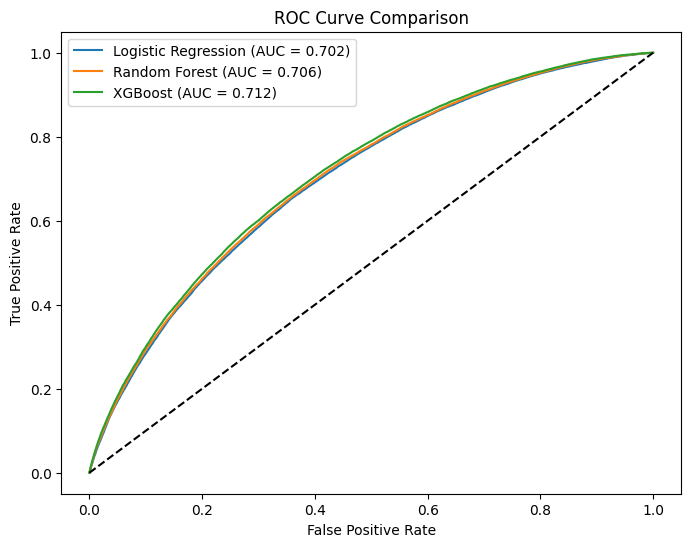

In [50]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    pipeline = create_pipeline()
    pipeline.set_params(model=model)
    
    pipeline.fit(X_train, y_train)
    
    prob = pipeline.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, prob)
    
    auc = roc_auc_score(y_test, prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [49]:
from sklearn.metrics import classification_report, roc_auc_score

pred = pipeline.predict(X_test)

prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))

print("ROC AUC:", roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74    208391
           1       0.32      0.67      0.43     52331

    accuracy                           0.64    260722
   macro avg       0.60      0.65      0.58    260722
weighted avg       0.77      0.64      0.68    260722

ROC AUC: 0.7124203700758066


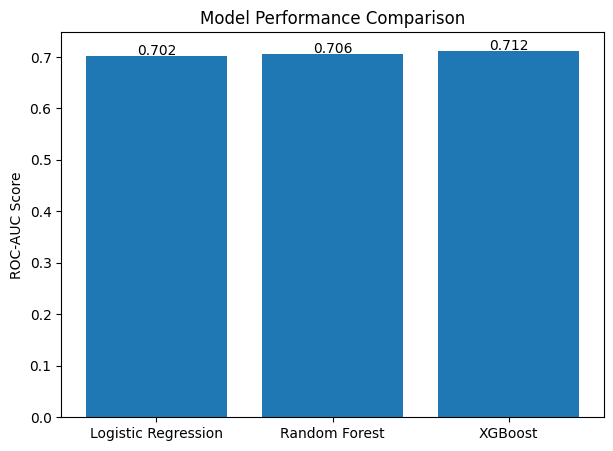

In [52]:
import matplotlib.pyplot as plt

models_list = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(7,5))

plt.bar(models_list, scores)

plt.ylabel("ROC-AUC Score")
plt.title("Model Performance Comparison")

for i, v in enumerate(scores):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

<Figure size 900x600 with 0 Axes>

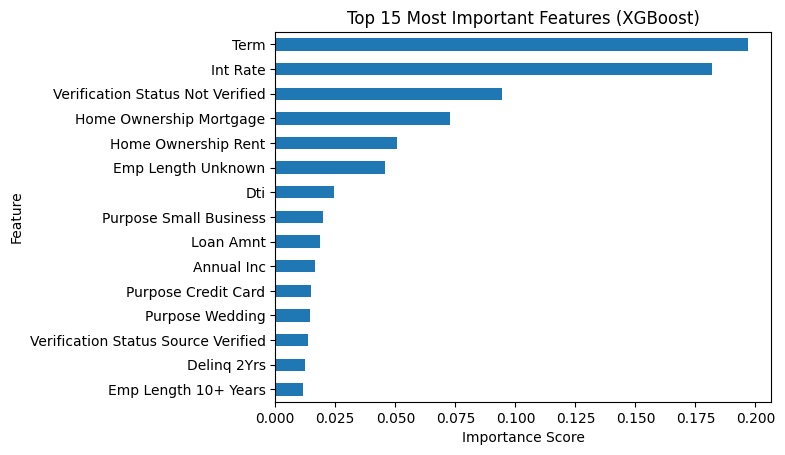

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# get trained XGBoost model
xgb_model = pipeline.named_steps["model"]

# get preprocessing step
preprocessor = pipeline.named_steps["preprocessor"]


# get feature names after encoding
feature_names = preprocessor.get_feature_names_out()
def clean_feature_name(name):

    name = name.replace("num__", "")
    name = name.replace("cat__", "")

    name = name.replace("_", " ")

    return name.title()
clean_names = [clean_feature_name(f) for f in feature_names]
#create dataframe
importance_df = pd.DataFrame({
    "Feature": clean_names,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
# get feature importances
importances = xgb_model.feature_importances_

# plot top 15 features
plt.figure(figsize=(9,6))

importance_df.head(15).sort_values("Importance").plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False
)

plt.title("Top 15 Most Important Features (XGBoost)")
plt.xlabel("Importance Score")

plt.show()



In [54]:
pip install shap


   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   --------------------------------------- 556.1/556.1 kB 18.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -------- ------------------------------- 7.9/38.1 MB 40.7 MB/s eta 0:00:01
   ------------------- -------------------- 18.9/38.1 MB 44.2 MB/s eta 0:00:01
   ----------------------------- ---------- 28.3/38.1 MB 46.1 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 45.6 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 42.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 40.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


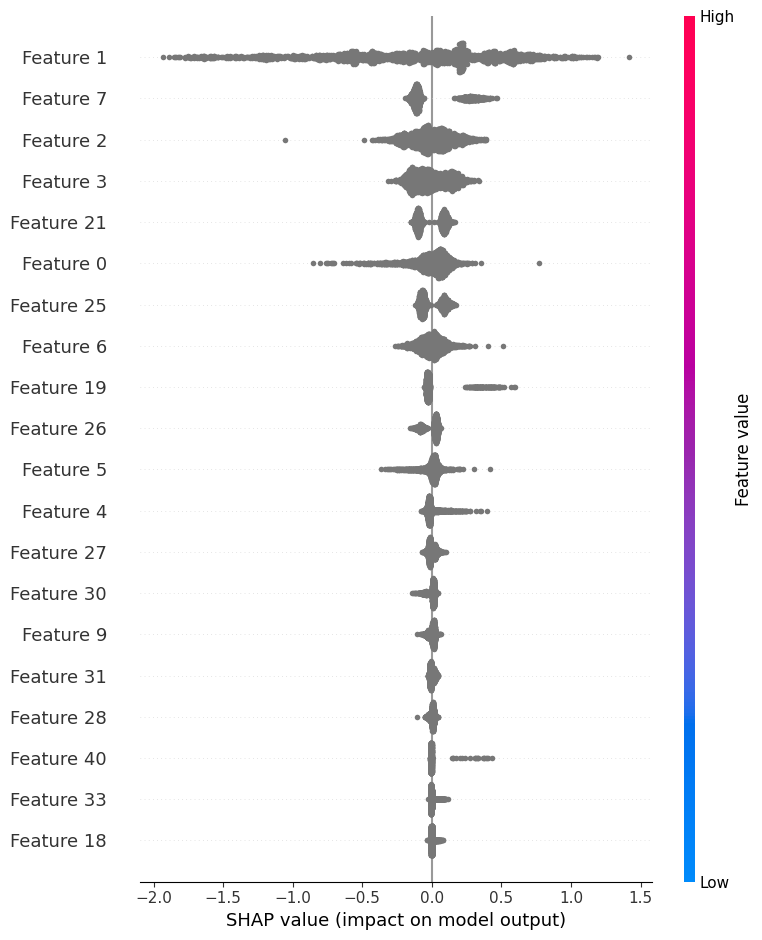

In [57]:
import shap

# get model from pipeline
xgb_model = pipeline.named_steps["model"]

# get preprocessing step
preprocessor = pipeline.named_steps["preprocessor"]

# transform test data exactly like training
X_test_transformed = preprocessor.transform(X_test)

# use smaller sample (SHAP is slow on 260k rows)
X_sample = X_test_transformed[:2000]

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [51]:
import joblib

joblib.dump(pipeline, "../models/creditriskmodel.pkl")

['../models/creditriskmodel.pkl']